In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../data/01_raw/bank_transactions_data_edited.csv')

In [4]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [6]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


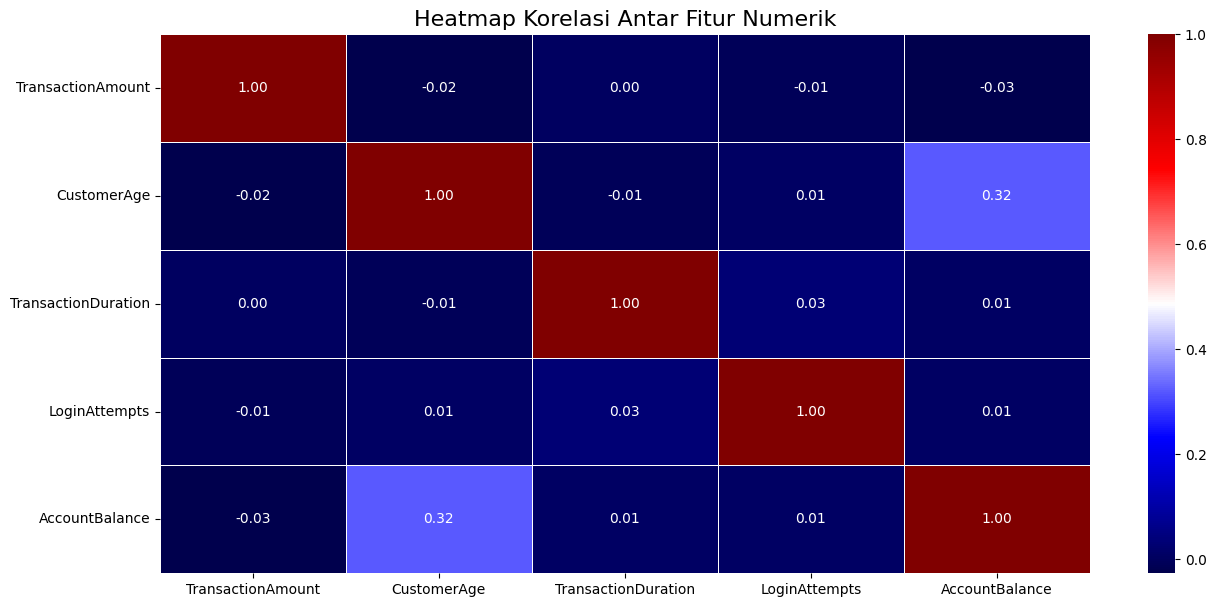

In [7]:
numerical_features = df.select_dtypes(include=np.number)
correlation_matrix = numerical_features.corr()

# print(correlation_matrix)

plt.figure(figsize=(15, 7))
sns.heatmap(
  correlation_matrix,
  annot=True,
  cmap='seismic',
  fmt='.2f',
  linewidths=.5
)
plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=16)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

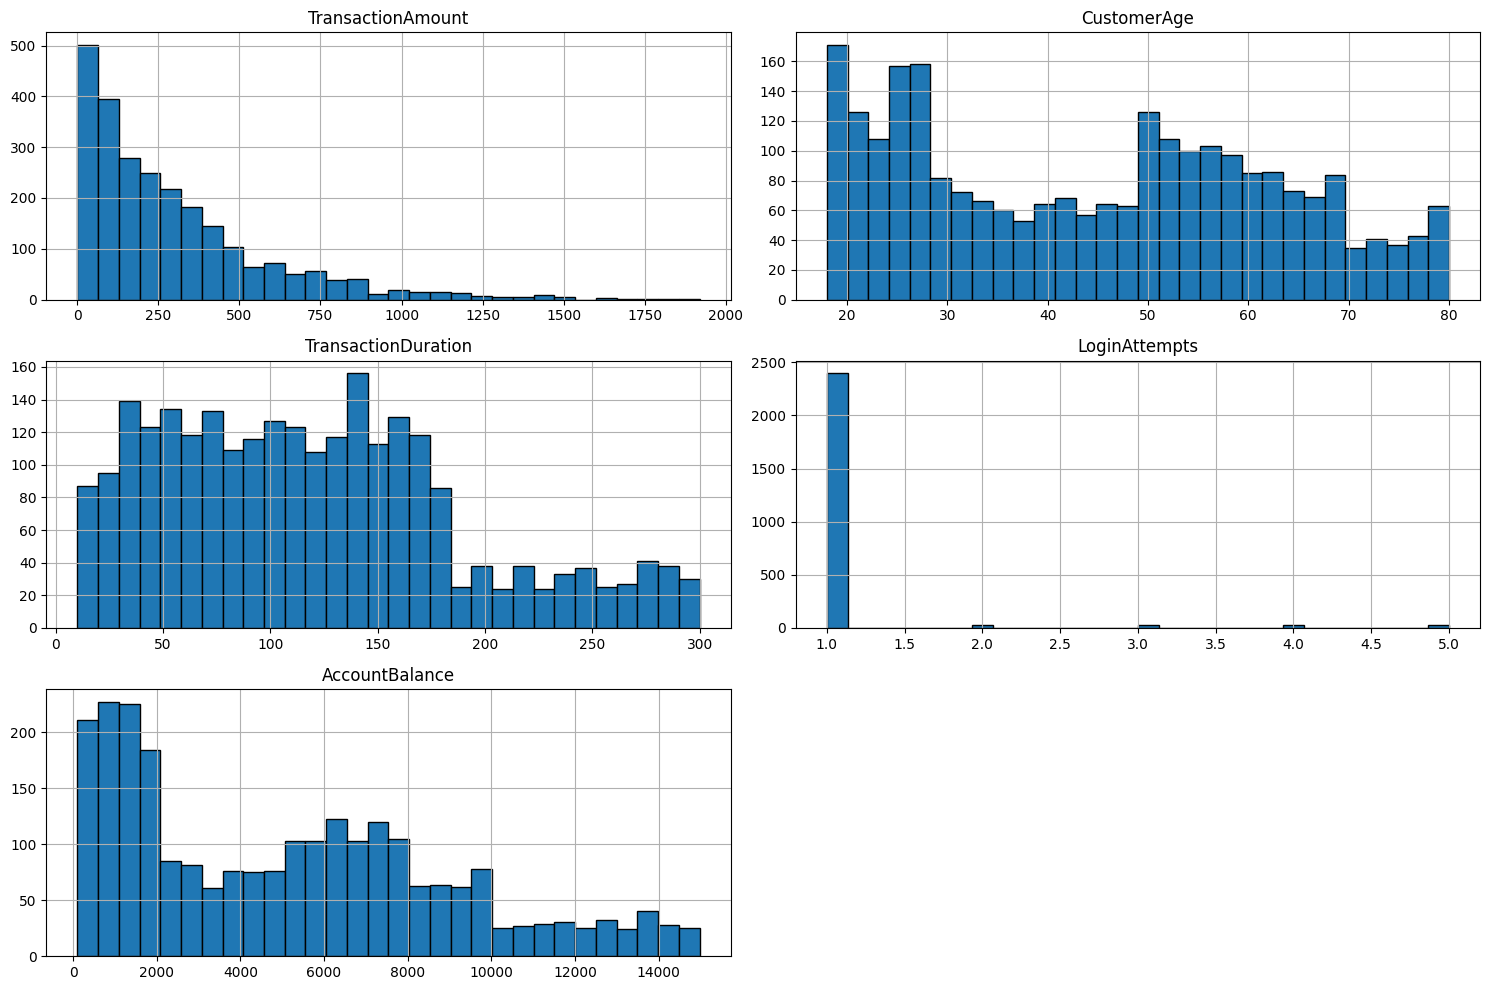

In [8]:
numerical_features.hist(
  figsize=(15, 10),
  bins=30,
  edgecolor='black'
)
plt.tight_layout()
plt.show

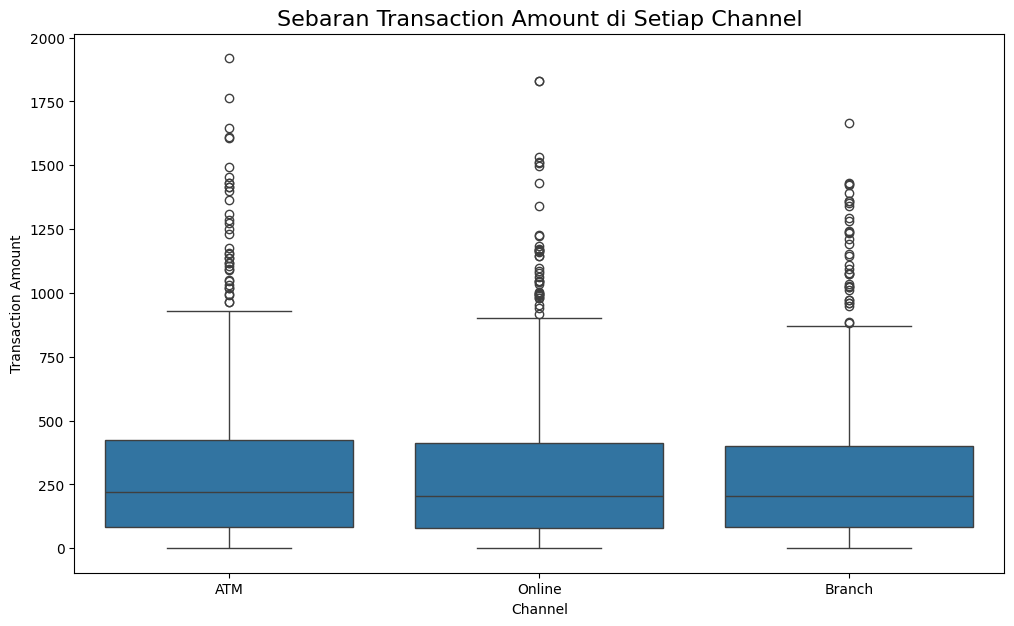

In [10]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Channel', y='TransactionAmount', data=df)
plt.title('Sebaran Transaction Amount di Setiap Channel', fontsize=16)
plt.ylabel('Transaction Amount')
plt.xlabel('Channel')
plt.show()

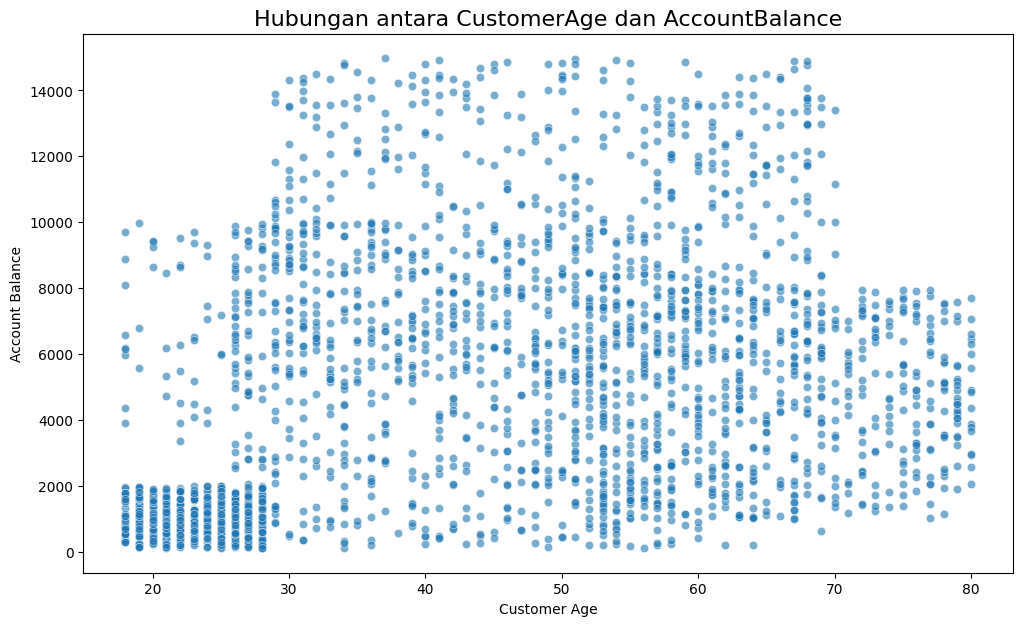

In [12]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='CustomerAge', y='AccountBalance', data=df, alpha=0.6)
plt.title('Hubungan antara CustomerAge dan AccountBalance', fontsize=16)
plt.xlabel('Customer Age')
plt.ylabel('Account Balance')
plt.show()

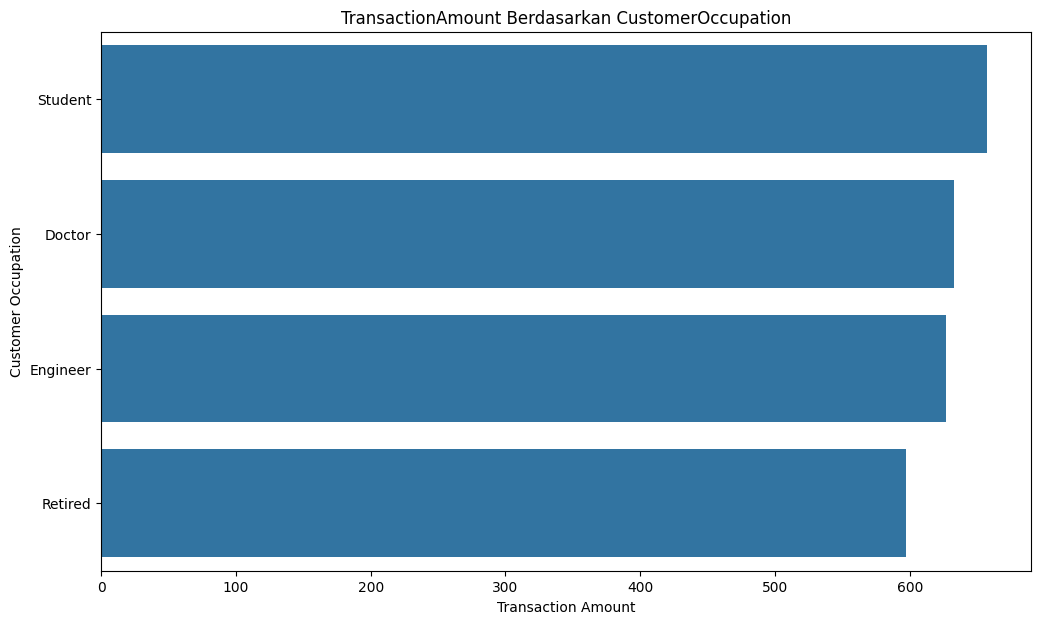

In [13]:
plt.figure(figsize=(12, 7))
sns.countplot(y='CustomerOccupation', data=df, order=df['CustomerOccupation'].value_counts().index)
plt.title('TransactionAmount Berdasarkan CustomerOccupation')
plt.xlabel('Transaction Amount')
plt.ylabel('Customer Occupation')
plt.show()